In [1]:
import sys
import subprocess
import os
from pathlib import Path
import tempfile

def setup_mfc_environment(install_silo=True):
    """Initialize MFC and install notebook packages, optionally install Silo"""
    print("=== MFC Environment Setup ===\n")
    
    # Check if we're in MFC root directory
    if not os.path.exists("mfc.sh"):
        print("❌ Error: mfc.sh not found")
        print("   Make sure you're running this notebook from the MFC root directory")
        return False, None
    
    print("🔧 Step 1: Initializing MFC virtual environment...")
    print("   Running: ./mfc.sh init")
    print("   (This may take several minutes on first run)")
    
    # Initialize MFC - creates virtual environment
    try:
        result = subprocess.run("./mfc.sh init", shell=True, capture_output=True, 
                              text=True, timeout=6000)
        if result.returncode != 0:
            print("❌ MFC initialization failed")
            print(f"   Error: {result.stderr}")
            return False, None
        print("✅ MFC initialized successfully\n")
    except subprocess.TimeoutExpired:
        print("❌ MFC initialization timed out")
        return False, None
    except Exception as e:
        print(f"❌ MFC initialization error: {e}")
        return False, None
    
    # Find MFC's virtual environment
    build_dir = Path("build")
    venv_path = None
    
    if build_dir.exists():
        for potential_venv in ["venv", ".venv", "env"]:
            candidate = build_dir / potential_venv
            if candidate.exists():
                venv_path = candidate
                break
    
    if not venv_path:
        print("❌ Could not find MFC's virtual environment")
        return False, None
    
    print(f"✅ Found MFC virtual environment: {venv_path}")
    
    # Get Python executable
    python_exe = venv_path / ("Scripts/python.exe" if sys.platform == "win32" else "bin/python")
    
    if not python_exe.exists():
        print(f"❌ Python executable not found: {python_exe}")
        return False, None
    
    # Install basic packages
    packages = ["matplotlib", "pandas", "h5py", "seaborn", "ipywidgets"]
    
    print("📦 Step 2: Installing notebook packages in MFC environment...")
    for package in packages:
        try:
            result = subprocess.run([str(python_exe), "-m", "pip", "install", package],
                                  capture_output=True, text=True, timeout=1200)
            if result.returncode == 0:
                print(f"   ✅ {package}")
            else:
                print(f"   ⚠️  {package} (failed)")
        except Exception as e:
            print(f"   ⚠️  {package} (error: {e})")
    
    # Optionally install Silo
    silo_success = False
    if install_silo:
        print("\n🔧 Step 3: Installing Silo library for MFC file analysis...")
        print("   (This may take 10+ minutes - building from source)")
        print("   Press Ctrl+C to skip Silo installation if taking too long")
        try:
            silo_success = install_silo_library(venv_path, python_exe)
        except KeyboardInterrupt:
            print("\n   ⚠️  Silo installation interrupted by user")
            print("   Continuing without Silo - basic analysis will still work")
            silo_success = False
    else:
        print("\n⏭️  Step 3: Skipping Silo installation (can install later)")
        print("   Note: Advanced Silo file analysis will not be available")
    
    return True, str(python_exe)

def install_silo_library(venv_path, python_exe):
    """Install Silo library with Python bindings for MFC file analysis"""
    
    # Check for required build tools first
    required_tools = ["git", "make", "gcc", "g++"]
    missing_tools = []
    
    for tool in required_tools:
        result = subprocess.run(["which", tool], capture_output=True)
        if result.returncode != 0:
            missing_tools.append(tool)
    
    if missing_tools:
        print(f"   ❌ Missing build tools: {', '.join(missing_tools)}")
        print("   Install with: brew install git make gcc (on macOS)")
        return False
    
    try:
        # Get Python version info from MFC's venv
        result = subprocess.run([str(python_exe), "-c", 
                               "import sys; print(f'{sys.version_info.major}.{sys.version_info.minor}')"],
                               capture_output=True, text=True)
        python_version = result.stdout.strip() if result.returncode == 0 else "3.12"
        
        # Find Python include directory - USE ABSOLUTE PATHS
        venv_abs = venv_path.absolute()
        python_exe_abs = python_exe.absolute()
        python_include = venv_abs / f"include/python{python_version}"
        
        if not python_include.exists():
            for alt in [venv_abs / "include", venv_abs / f"include/python{python_version}m"]:
                if alt.exists():
                    python_include = alt
                    break
        
        python_include_abs = python_include.absolute()
        print(f"   Using Python {python_version}, include: {python_include_abs}")
        
        # Create temporary directory for building Silo
        with tempfile.TemporaryDirectory() as temp_dir:
            temp_path = Path(temp_dir)
            silo_dir = temp_path / "Silo"
            
            # Clone Silo repository
            print("   Cloning Silo repository...")
            result = subprocess.run(
                ["git", "clone", "https://github.com/LLNL/Silo.git", str(silo_dir)],
                capture_output=True, text=True, timeout=3000
            )
            
            if result.returncode != 0:
                print(f"   ❌ Failed to clone Silo: {result.stderr}")
                return False
            
            print("   ✅ Silo repository cloned")
            
            # Configure Silo with ABSOLUTE PATHS (this was the bug!)
            print("   Configuring Silo...")
            silo_prefix_abs = (venv_abs / "silo_install").absolute()
            
            # Check for HDF5 installation (needed for MFC's Silo files)
            hdf5_path = None
            for hdf5_check in ["/opt/homebrew", "/usr/local", "/usr"]:
                if Path(f"{hdf5_check}/include/hdf5.h").exists():
                    hdf5_path = hdf5_check
                    break
            
            configure_cmd = [
                "./configure",
                f"--prefix={silo_prefix_abs}",
                "--enable-pythonmodule",
                f"--with-python={python_exe_abs}",
                f"--includedir={python_include_abs}",
                "--with-hdf5"
            ]
            
            # Add HDF5 path if found
            if hdf5_path:
                configure_cmd.extend([f"--with-hdf5={hdf5_path}", f"CPPFLAGS=-I{hdf5_path}/include", f"LDFLAGS=-L{hdf5_path}/lib"])
                print(f"   Using HDF5 from: {hdf5_path}")
            else:
                print("   Warning: HDF5 not found - trying system default")
                # Try to find HDF5 via pkg-config or use system default
                try:
                    result = subprocess.run(["brew", "--prefix", "hdf5"], capture_output=True, text=True)
                    if result.returncode == 0:
                        brew_hdf5 = result.stdout.strip()
                        configure_cmd.extend([f"--with-hdf5={brew_hdf5}"])
                        print(f"   Found HDF5 via brew: {brew_hdf5}")
                except:
                    pass
            
            print(f"   Configure command: {' '.join(configure_cmd)}")
            
            result = subprocess.run(
                configure_cmd, cwd=silo_dir, capture_output=True, text=True, timeout=6000
            )
            
            if result.returncode != 0:
                print(f"   ❌ Silo configure failed")
                print(f"   Configure output: {result.stderr[-500:]}")
                return False
            
            print("   ✅ Silo configured successfully")
            
            # Build and install Silo
            print("   Building Silo (this takes several minutes)...")
            result = subprocess.run(
                ["make", "-j10"], cwd=silo_dir, capture_output=True, text=True, timeout=18000
            )
            
            if result.returncode != 0:
                print(f"   ❌ Silo build failed")
                print(f"   Build error: {result.stderr[-500:]}")
                return False
            
            print("   ✅ Silo built successfully")
            
            print("   Installing Silo...")
            result = subprocess.run(
                ["make", "install"], cwd=silo_dir, capture_output=True, text=True, timeout=30000
            )
            
            if result.returncode != 0:
                print(f"   ❌ Silo install failed")
                print(f"   Install error: {result.stderr[-500:]}")
                return False
            
            print("   ✅ Silo installed successfully")
            
            # Find and add Silo to Python path - check multiple possible locations
            silo_installed = False
            possible_python_paths = [
                silo_prefix_abs / "lib" / f"python{python_version}" / "site-packages",
                silo_prefix_abs / "lib" / "python" / "site-packages", 
                silo_prefix_abs / f"lib/python{python_version}/site-packages",
                silo_prefix_abs / "lib",
                silo_prefix_abs / "lib64" / f"python{python_version}" / "site-packages"
            ]
            
            for silo_python_path in possible_python_paths:
                if silo_python_path.exists():
                    # Check if Silo files are actually there
                    silo_files = list(silo_python_path.glob("*Silo*")) + list(silo_python_path.glob("*silo*"))
                    if silo_files:
                        print(f"   Found Silo in: {silo_python_path}")
                        
                        # Add to PYTHONPATH via .pth file
                        pth_file = venv_abs / "lib" / f"python{python_version}" / "site-packages" / "silo.pth"
                        pth_file.parent.mkdir(parents=True, exist_ok=True)
                        with open(pth_file, 'w') as f:
                            f.write(str(silo_python_path))
                        
                        # Also try setting PYTHONPATH environment variable for the test
                        env = os.environ.copy()
                        current_pythonpath = env.get('PYTHONPATH', '')
                        if current_pythonpath:
                            env['PYTHONPATH'] = f"{silo_python_path}:{current_pythonpath}"
                        else:
                            env['PYTHONPATH'] = str(silo_python_path)
                        
                        # Test Silo import with explicit PYTHONPATH
                        result = subprocess.run([str(python_exe_abs), "-c", "import Silo; print('Silo version:', Silo.Version())"],
                                              capture_output=True, text=True, env=env)
                        
                        if result.returncode == 0:
                            print(f"   ✅ Silo Python module working: {result.stdout.strip()}")
                            silo_installed = True
                            break
                        else:
                            print(f"   Testing path {silo_python_path}: {result.stderr.strip()}")
            
            if not silo_installed:
                print(f"   ⚠️  Silo installed but Python module not found in expected locations")
                print(f"   Checked: {[str(p) for p in possible_python_paths]}")
                return False
            
            return True
                
    except Exception as e:
        print(f"   ❌ Silo installation error: {e}")
        return False

# Setup options - change install_silo to True if you want automatic Silo installation
INSTALL_SILO = True  # Set to True for full Silo support (takes 10+ minutes)

print("🚀 Starting MFC environment setup...")
print(f"   Silo installation: {'Enabled' if INSTALL_SILO else 'Disabled (can enable later)'}")
print("   💡 To enable Silo: set INSTALL_SILO = True above and re-run this cell")
print("")

success, mfc_python = setup_mfc_environment(install_silo=INSTALL_SILO)

if success:
    print(f"\n🎉 Setup Complete!")
    print(f"   MFC Python: {mfc_python}")
    
    # Import packages and set up environment
    import json, glob, time, warnings
    import numpy as np
    
    # Set global flags for available packages
    MFC_ROOT = os.getcwd()
    PACKAGES = {}
    
    for pkg_name, import_name in [("matplotlib", "matplotlib.pyplot"), ("pandas", "pandas"), 
                                  ("h5py", "h5py"), ("seaborn", "seaborn"), ("ipywidgets", "ipywidgets")]:
        try:
            __import__(import_name)
            PACKAGES[pkg_name] = True
            print(f"   ✅ {pkg_name} available")
        except ImportError:
            PACKAGES[pkg_name] = False
            print(f"   ❌ {pkg_name} not available")
    
    # Check for Silo specifically - test in MFC's Python environment
    try:
        # Test Silo import in MFC's venv (where it was installed)
        result = subprocess.run([mfc_python, "-c", "import Silo; print('Silo available')"],
                              capture_output=True, text=True, timeout=1000)
        if result.returncode == 0:
            PACKAGES["silo"] = True
            print(f"   ✅ Silo available")
        else:
            PACKAGES["silo"] = False
            print(f"   ❌ Silo import failed in MFC environment: {result.stderr}")
    except Exception as e:
        PACKAGES["silo"] = False
        print(f"   ❌ Silo test failed: {e}")
        print(f"   ℹ️  Set INSTALL_SILO=True to enable Silo installation")
    
    # Set up plotting if available
    if PACKAGES["matplotlib"]:
        import matplotlib.pyplot as plt
        if PACKAGES["seaborn"]:
            import seaborn as sns
            sns.set_palette("husl")
            plt.style.use('seaborn-v0_8')
        else:
            plt.style.use('default')
    
    warnings.filterwarnings('ignore')
    
else:
    print("\n❌ Setup failed. Check errors above and ensure:")
    print("   1. You're in the MFC root directory")
    print("   2. You have internet access")
    print("   3. For Silo: build tools (git, make, gcc)")

# Optional: Manual Silo installation function
def install_silo_now():
    """Install Silo manually if skipped during setup"""
    if success and not PACKAGES.get("silo"):
        print("Installing Silo library...")
        venv_path = Path("build/venv")  # Adjust if needed
        python_exe = venv_path / "bin/python"
        return install_silo_library(venv_path, python_exe)
    else:
        print("Silo already available or setup failed")
        return False


🚀 Starting MFC environment setup...
   Silo installation: Enabled
   💡 To enable Silo: set INSTALL_SILO = True above and re-run this cell

=== MFC Environment Setup ===

🔧 Step 1: Initializing MFC virtual environment...
   Running: ./mfc.sh init
   (This may take several minutes on first run)
✅ MFC initialized successfully

✅ Found MFC virtual environment: build/venv
📦 Step 2: Installing notebook packages in MFC environment...
   ✅ matplotlib
   ✅ pandas
   ✅ h5py
   ✅ seaborn
   ✅ ipywidgets

🔧 Step 3: Installing Silo library for MFC file analysis...
   (This may take 10+ minutes - building from source)
   Press Ctrl+C to skip Silo installation if taking too long
   Using Python 3.13, include: /Users/spencer/Downloads/MFC-spencer/build/venv/include/python3.13
   Cloning Silo repository...
   ✅ Silo repository cloned
   Configuring Silo...
   Using HDF5 from: /opt/homebrew
   Configure command: ./configure --prefix=/Users/spencer/Downloads/MFC-spencer/build/venv/silo_install --enable-p

In [2]:
def build_mfc(targets=['pre_process', 'simulation', 'post_process'], mpi=True, jobs=None):
    """Build MFC with specified options - includes post_process for Silo file generation"""
    # Check if we have the success variable from setup
    try:
        if not success:
            print("❌ Cannot build - environment setup failed")
            return False
    except NameError:
        print("❌ Cannot build - run the setup cell first")
        return False
    
    print(f"=== Building MFC ===")
    print(f"Targets: {', '.join(targets)}")
    print("ℹ️  Including post_process for Silo visualization data generation")
    
    # Determine number of jobs
    if jobs is None:
        try:
            jobs = int(subprocess.run("nproc", shell=True, capture_output=True, text=True).stdout.strip())
        except:
            jobs = 4
    
    # Build command
    cmd = f"./mfc.sh build -j {jobs} -t {' '.join(targets)}"
    if mpi:
        cmd += " --mpi"
    
    print(f"Running: {cmd}")
    
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=1800)
        if result.returncode == 0:
            print("✅ MFC build successful!")
            print("✅ All components built: pre_process, simulation, post_process")
            return True
        else:
            print("❌ MFC build failed")
            print(f"Error: {result.stderr[-500:]}")
            return False
    except subprocess.TimeoutExpired:
        print("❌ Build timed out after 30 minutes")
        return False

# Build MFC if environment setup was successful
try:
    if success:
        print("🔨 Starting MFC build...")
        build_success = build_mfc()
    else:
        build_success = False
        print("Skipping build due to environment setup failure")
except NameError:
    print("❌ Setup variables not found - run the setup cell first")
    build_success = False


🔨 Starting MFC build...
=== Building MFC ===
Targets: pre_process, simulation, post_process
ℹ️  Including post_process for Silo visualization data generation
Running: ./mfc.sh build -j 10 -t pre_process simulation post_process --mpi
✅ MFC build successful!
✅ All components built: pre_process, simulation, post_process


In [3]:
def list_examples():
    """List all available MFC examples"""
    examples_dir = Path("examples")
    examples = []
    
    if examples_dir.exists():
        for item in examples_dir.iterdir():
            case_file = item / "case.py"
            if item.is_dir() and case_file.exists():
                examples.append({
                    'name': item.name,
                    'path': str(item),
                    'case_file': str(case_file),
                    'dimension': item.name[:2] if item.name[0].isdigit() else 'Unknown'
                })
    
    return sorted(examples, key=lambda x: (x['dimension'], x['name']))

def run_example(example_name, stages=['pre_process', 'simulation', 'post_process'], num_procs=2, timeout=600):
    """Run a specific MFC example - includes post_process by default for Silo file generation"""
    if not build_success:
        print("❌ Cannot run examples - MFC build failed")
        return None
    
    # Find available examples
    examples_list = list_examples()
    
    # Find the example
    example_path = None
    for ex in examples_list:
        if ex['name'] == example_name:
            example_path = ex['case_file']
            break
    
    if not example_path:
        print(f"❌ Example '{example_name}' not found!")
        print("Available examples:")
        for ex in examples_list[:10]:
            print(f"  • {ex['name']}")
        return None
    
    print(f"=== Running Example: {example_name} ===")
    print(f"Stages: {', '.join(stages)}")
    print(f"Processors: {num_procs}")
    
    if 'post_process' in stages:
        print("✅ Post-processing enabled - will generate Silo files for visualization")
    else:
        print("⚠️  Post-processing disabled - no Silo visualization files will be generated")
    
    cmd = f"./mfc.sh run {example_path} -n {num_procs} -t {' '.join(stages)} --no-build"
    print(f"Running: {cmd}")
    
    start_time = time.time()
    
    try:
        result = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout)
        runtime = time.time() - start_time
        
        if result.returncode == 0:
            print(f"✅ Example completed successfully in {runtime:.1f}s")
            
            # Check for output files
            example_dir = Path(example_path).parent
            output_dirs = ['silo_hdf5', 'restart_data', 'D', 'silo', 'hdf5']
            
            silo_files_found = False
            for output_dir in output_dirs:
                full_path = example_dir / output_dir
                if full_path.exists():
                    files = list(full_path.iterdir())
                    silo_count = len([f for f in files if f.suffix in ['.silo', '.h5', '.hdf5']])
                    print(f"   Output: {output_dir}/ ({len(files)} files, {silo_count} Silo/HDF5)")
                    if silo_count > 0:
                        silo_files_found = True
            
            if silo_files_found:
                print("✅ Silo/HDF5 visualization files generated successfully")
            elif 'post_process' in stages:
                print("⚠️  Post-processing ran but no Silo files found")
            else:
                print("ℹ️  No Silo files (post-processing not included)")
            
            return {
                'success': True,
                'runtime': runtime,
                'example_dir': str(example_dir),
                'stdout': result.stdout,
                'stderr': result.stderr
            }
        else:
            print(f"❌ Example failed after {runtime:.1f}s")
            print(f"Error: {result.stderr[-300:]}")
            return {'success': False, 'runtime': runtime, 'stderr': result.stderr}
            
    except subprocess.TimeoutExpired:
        print(f"❌ Example timed out after {timeout}s")
        return {'success': False, 'runtime': timeout, 'stderr': 'Timeout'}

def analyze_results(run_result):
    """Analyze and visualize MFC results with Silo (if available) or basic file analysis"""
    if not run_result or not run_result['success']:
        print("No successful run to analyze")
        return
    
    print(f"=== Results Analysis ===")
    print(f"Runtime: {run_result['runtime']:.2f} seconds")
    
    example_dir = Path(run_result['example_dir'])
    
    # Find MFC Silo output files (they're in subdirectories)
    output_files = {'silo': [], 'collection': [], 'other': []}
    
    for output_dir in ['silo_hdf5', 'D', 'hdf5', 'silo']:
        dir_path = example_dir / output_dir
        if dir_path.exists():
            print(f"📁 Checking {output_dir}/ directory...")
            
            # Look for collection files in root/ subdirectory (these are the main files)
            root_dir = dir_path / 'root'
            if root_dir.exists():
                collection_files = list(root_dir.glob('collection_*.silo'))
                if collection_files:
                    output_files['collection'].extend(collection_files)
                    print(f"   Found {len(collection_files)} collection files in root/")
                    for f in collection_files[:3]:  # Show first 3
                        print(f"     • {f.name} ({f.stat().st_size/1024:.1f} KB)")
                    if len(collection_files) > 3:
                        print(f"     ... and {len(collection_files) - 3} more")
            
            # Also check for individual rank files and other silo files
            for item in dir_path.iterdir():
                if item.is_file() and item.suffix in ['.silo', '.h5', '.hdf5']:
                    output_files['silo'].append(item)
                elif item.is_dir():
                    # Check subdirectories for .silo files
                    silo_files = list(item.glob('*.silo'))
                    if silo_files:
                        output_files['silo'].extend(silo_files[:5])  # Limit to avoid spam
                        print(f"   Found {len(silo_files)} files in {item.name}/")
    
    total_silo = len(output_files['silo']) + len(output_files['collection'])
    print(f"\\nFound {len(output_files['collection'])} collection files, {len(output_files['silo'])} other Silo files")
    
    if not output_files['collection'] and not output_files['silo']:
        print("❌ No Silo files found for analysis!")
        print("   Make sure post_process was included in the run stages.")
        print("   Expected structure: silo_hdf5/root/collection_*.silo")
        return
    
    # Try Silo analysis first (if available) - prefer collection files
    if PACKAGES.get('silo'):
        print("🔧 Using Silo for full MFC file analysis...")
        try:
            # Use collection files if available (these are the master files)
            if output_files['collection']:
                analyze_with_silo(output_files['collection'][0], example_dir, mfc_python)
            elif output_files['silo']:
                analyze_with_silo(output_files['silo'][0], example_dir, mfc_python)
            else:
                print("❌ No Silo files to analyze")
        except Exception as e:
            print(f"⚠️ Silo analysis failed: {e}")
            print("   Trying HDF5 analysis (MFC Silo files are HDF5-backed)...")
            try:
                analyze_mfc_hdf5_silo(output_files['collection'][0] if output_files['collection'] else output_files['silo'][0])
            except Exception as e2:
                print(f"   HDF5 analysis also failed: {e2}")
                print("   Falling back to basic analysis...")
                all_files = output_files['collection'] + output_files['silo']
                analyze_basic(all_files, example_dir)
    else:
        print("📊 Using basic file analysis (Silo not available)")
        all_files = output_files['collection'] + output_files['silo']
        analyze_basic(all_files, example_dir)

def analyze_with_silo(file_path, example_dir, python_exe):
    """Analyze MFC files using Silo library in MFC's Python environment"""
    print(f"📊 Analyzing with Silo: {file_path.name}")
    
    # Create a script to run Silo analysis in MFC's Python for MFC collection files
    analysis_script = f'''
import sys
sys.path.insert(0, "/")  # Ensure we can import Silo
import Silo
import numpy as np

try:
    # Open Silo collection file
    db = Silo.Open("{file_path}", Silo.DB_READ)
    
    # Get table of contents
    toc = db.GetToc()
    
    print(f"File type: Collection file (MFC parallel output)")
    print(f"Variables: {{len(toc.var_names) if toc.var_names else 0}}")
    print(f"Meshes: {{len(toc.mesh_names) if toc.mesh_names else 0}}")
    print(f"Multimeshes: {{len(toc.multimesh_names) if toc.multimesh_names else 0}}")
    print(f"Multivars: {{len(toc.multivar_names) if toc.multivar_names else 0}}")
    
    # For MFC collection files, we want to look at multivars (these combine data from all ranks)
    if toc.multivar_names:
        print("\\nAvailable multivars (combined from all ranks):")
        for var_name in toc.multivar_names[:10]:
            print(f"  • {{var_name}}")
        if len(toc.multivar_names) > 10:
            print(f"  ... and {{len(toc.multivar_names) - 10}} more")
        
        # Try to analyze first multivar
        var_name = toc.multivar_names[0]
        try:
            print(f"\\nAnalyzing multivar: {{var_name}}")
            multivar_info = db.GetMultivar(var_name)
            print(f"  Type: {{type(multivar_info)}}")
            print(f"  Info: {{multivar_info}}")
            
            # For collection files, we might need to read individual blocks
            # This is more complex - just show the structure for now
            
        except Exception as e:
            print(f"Could not read multivar {{var_name}}: {{e}}")
    
    elif toc.var_names:
        print("\\nAvailable variables:")
        for var_name in toc.var_names[:10]:
            print(f"  • {{var_name}}")
        if len(toc.var_names) > 10:
            print(f"  ... and {{len(toc.var_names) - 10}} more")
        
        # Try to get basic info about first variable
        var_name = toc.var_names[0]
        try:
            var_data = db.GetVar(var_name)
            data = np.array(var_data)
            print(f"\\nSample variable {{var_name}}: shape {{data.shape}}, dtype {{data.dtype}}")
            if data.size > 0:
                print(f"  Min: {{data.min():.3e}}, Max: {{data.max():.3e}}")
        except Exception as e:
            print(f"Could not analyze {{var_name}}: {{e}}")
    
    else:
        print("\\nNo direct variables found - this is typical for collection files")
        print("Collection files reference data in individual rank files")
    
    db.Close()
    print("\\n✅ Silo collection analysis completed successfully")
    
except Exception as e:
    print(f"❌ Silo analysis error: {{e}}")
    import traceback
    traceback.print_exc()
    sys.exit(1)
'''
    
    # Run the analysis script in MFC's Python environment
    try:
        result = subprocess.run([python_exe, "-c", analysis_script],
                              capture_output=True, text=True, timeout=30)
        
        if result.returncode == 0:
            print(result.stdout)
        else:
            print(f"Silo analysis failed: {result.stderr}")
            raise Exception("Silo script failed")
            
    except Exception as e:
        raise Exception(f"Failed to run Silo analysis: {e}")

def analyze_mfc_hdf5_silo(file_path):
    """Analyze MFC's HDF5-backed Silo files using h5py when Silo library fails"""
    if not PACKAGES.get('h5py'):
        raise Exception("h5py not available for HDF5 analysis")
    
    import h5py
    print(f"📊 Analyzing MFC HDF5-Silo file: {file_path.name}")
    
    try:
        with h5py.File(file_path, 'r') as f:
            print(f"   File size: {file_path.stat().st_size/1024:.1f} KB")
            print(f"   HDF5 groups: {len(list(f.keys()))}")
            
            # Look for common MFC variable groups
            found_vars = []
            var_info = []
            
            def find_datasets(name, obj):
                if isinstance(obj, h5py.Dataset):
                    found_vars.append(name)
                    shape = obj.shape
                    dtype = obj.dtype
                    if obj.size > 0:
                        try:
                            data_sample = obj[...]
                            if hasattr(data_sample, 'min'):
                                var_info.append({
                                    'name': name,
                                    'shape': shape,
                                    'dtype': str(dtype),
                                    'min': float(data_sample.min()),
                                    'max': float(data_sample.max()),
                                    'data': data_sample
                                })
                        except:
                            var_info.append({
                                'name': name,
                                'shape': shape,
                                'dtype': str(dtype),
                                'min': None,
                                'max': None,
                                'data': None
                            })
            
            f.visititems(find_datasets)
            
            print(f"   Found {len(found_vars)} datasets:")
            for var in var_info[:10]:  # Show first 10
                if var['min'] is not None:
                    print(f"     • {var['name']}: {var['shape']} {var['dtype']} [{var['min']:.3e}, {var['max']:.3e}]")
                else:
                    print(f"     • {var['name']}: {var['shape']} {var['dtype']}")
            
            if len(found_vars) > 10:
                print(f"     ... and {len(found_vars) - 10} more")
            
            # Try to plot some data if matplotlib is available
            if PACKAGES.get('matplotlib') and var_info:
                plot_mfc_data(var_info, file_path.name)
            
            print("✅ HDF5-Silo analysis completed successfully")
            
    except Exception as e:
        raise Exception(f"Failed to read HDF5-Silo file: {e}")

def plot_mfc_data(var_info, filename):
    """Plot MFC data from HDF5-Silo analysis"""
    import matplotlib.pyplot as plt
    
    # Find plottable variables (1D arrays with reasonable size)
    plottable = []
    for var in var_info:
        if var['data'] is not None and len(var['shape']) == 1 and var['shape'][0] < 10000:
            plottable.append(var)
    
    if not plottable:
        print("   No suitable 1D data found for plotting")
        return
    
    # Plot up to 3 variables
    n_plots = min(len(plottable), 3)
    if n_plots > 0:
        fig, axes = plt.subplots(n_plots, 1, figsize=(12, 4*n_plots))
        if n_plots == 1:
            axes = [axes]
        
        fig.suptitle(f'MFC Results: {filename}', fontsize=16)
        
        for i, var in enumerate(plottable[:n_plots]):
            x = range(len(var['data']))
            axes[i].plot(x, var['data'], 'b-', linewidth=2)
            axes[i].set_title(f"{var['name']} (shape: {var['shape']})")
            axes[i].set_ylabel(var['name'])
            axes[i].grid(True, alpha=0.3)
            if var['min'] is not None:
                axes[i].text(0.02, 0.98, f"Range: [{var['min']:.3e}, {var['max']:.3e}]", 
                           transform=axes[i].transAxes, va='top', fontsize=10,
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        axes[-1].set_xlabel('Index')
        plt.tight_layout()
        plt.show()
        print(f"   ✅ Plotted {n_plots} variables")

def analyze_basic(silo_files, example_dir):
    """Basic file analysis when Silo is not available"""
    print(f"📊 Basic file analysis of {len(silo_files)} files:")
    
    total_size = 0
    for file in silo_files:
        size = file.stat().st_size
        total_size += size
        print(f"   {file.name}: {size/1024:.1f} KB")
    
    print(f"Total output size: {total_size/1024:.1f} KB")
    
    # Try to plot with h5py if available and files are HDF5
    if PACKAGES.get('matplotlib') and PACKAGES.get('h5py'):
        hdf5_files = [f for f in silo_files if f.suffix in ['.h5', '.hdf5']]
        if hdf5_files:
            try:
                plot_basic_hdf5(hdf5_files[0])
            except Exception as e:
                print(f"⚠️ Could not plot HDF5 data: {e}")

def plot_basic_hdf5(file_path):
    """Basic HDF5 plotting if the file is actually HDF5 format"""
    import matplotlib.pyplot as plt
    import h5py
    
    print(f"🎯 Attempting basic HDF5 plot: {file_path.name}")
    
    try:
        with h5py.File(file_path, 'r') as f:
            # List datasets
            datasets = []
            def find_datasets(name, obj):
                if isinstance(obj, h5py.Dataset):
                    datasets.append(name)
            f.visititems(find_datasets)
            
            if datasets:
                print(f"   Found {len(datasets)} datasets")
                # Try to plot first dataset
                data = f[datasets[0]][:]
                if len(data.shape) == 1 and len(data) > 1:
                    plt.figure(figsize=(10, 6))
                    plt.plot(data)
                    plt.title(f'{file_path.name}: {datasets[0]}')
                    plt.xlabel('Index')
                    plt.ylabel('Value')
                    plt.grid(True, alpha=0.3)
                    plt.show()
                    print("✅ Basic plot generated")
                else:
                    print(f"   Data shape {data.shape} - not suitable for basic line plot")
            else:
                print("   No plottable datasets found")
                
    except Exception as e:
        print(f"   Not a valid HDF5 file or read error: {e}")

# Quick demo if build was successful
if build_success:
    examples = list_examples()
    if examples:
        print(f"\\n📚 Found {len(examples)} examples:")
        for ex in examples[:5]:
            print(f"   • {ex['name']}")
        if len(examples) > 5:
            print(f"   ... and {len(examples) - 5} more")
        print("\\n🚀 To run an example:")
        print("run_result = run_example('1D_sodshocktube')")
        print("analyze_results(run_result)")
    else:
        print("No examples found")
else:
    print("Build failed - cannot run examples")


\n📚 Found 117 examples:
   • 0D_bubblecollapse_adap
   • 1D_acoustic_dipole
   • 1D_acoustic_gauss_sigmadist
   • 1D_acoustic_gauss_sigmatime
   • 1D_acoustic_sine_frequency
   ... and 112 more
\n🚀 To run an example:
run_result = run_example('1D_sodshocktube')
analyze_results(run_result)


In [4]:
import sys
import subprocess
import os
from pathlib import Path

def run_command(cmd, cwd=None, capture_output=True, text=True, timeout=300):
    """Helper function to run shell commands with error handling"""
    try:
        result = subprocess.run(
            cmd, 
            shell=True, 
            cwd=cwd or os.getcwd(),
            capture_output=capture_output,
            text=text,
            timeout=timeout
        )
        return result
    except subprocess.TimeoutExpired:
        print(f"Command timed out after {timeout} seconds: {cmd}")
        return None
    except Exception as e:
        print(f"Error running command '{cmd}': {e}")
        return None

def initialize_mfc_venv():
    """Initialize MFC's virtual environment first"""
    print("=== Initializing MFC Virtual Environment ===")
    
    # Check if we're in MFC root
    if not os.path.exists("mfc.sh"):
        print("❌ mfc.sh not found. Make sure you're in the MFC root directory.")
        return None
    
    print("Running ./mfc.sh init to create MFC's virtual environment...")
    print("(This may take a few minutes on first run)")
    
    # Initialize MFC - this creates the virtual environment
    result = run_command("./mfc.sh init", timeout=600)
    
    if result and result.returncode == 0:
        print("✓ MFC initialization completed successfully")
        
        # Find MFC's virtual environment
        build_dir = Path("build")
        if build_dir.exists():
            # MFC typically creates venv in build/ directory
            possible_venv_paths = [
                build_dir / "venv",
                build_dir / ".venv", 
                build_dir / "env"
            ]
            
            for venv_path in possible_venv_paths:
                if venv_path.exists():
                    print(f"✓ Found MFC virtual environment: {venv_path}")
                    return venv_path
            
            print("⚠️  MFC build directory exists but couldn't find virtual environment")
            print("    Checking build directory contents...")
            for item in build_dir.iterdir():
                if item.is_dir() and ("venv" in item.name or "env" in item.name):
                    print(f"    Found potential venv: {item}")
                    return item
        
        print("⚠️  Could not locate MFC's virtual environment")
        return None
    else:
        print("❌ Failed to initialize MFC")
        if result:
            print(f"Error: {result.stderr}")
        return None

def get_mfc_python(venv_path):
    """Get Python executable from MFC's virtual environment"""
    if sys.platform == "win32":
        python_exe = venv_path / "Scripts" / "python.exe"
    else:
        python_exe = venv_path / "bin" / "python"
    
    if python_exe.exists():
        return str(python_exe)
    else:
        print(f"❌ Python executable not found in {python_exe}")
        return None

def install_package_in_mfc_venv(package_name, python_exe, import_name=None):
    """Install package in MFC's virtual environment if not available"""
    if import_name is None:
        import_name = package_name
    
    # First check if already available in current environment
    try:
        __import__(import_name)
        print(f"✓ {package_name} already available")
        return True
    except ImportError:
        pass
    
    # Install in MFC's virtual environment
    print(f"Installing {package_name} in MFC's virtual environment...")
    try:
        result = subprocess.run([python_exe, "-m", "pip", "install", package_name], 
                              capture_output=True, text=True, timeout=120)
        if result.returncode == 0:
            print(f"✓ {package_name} installed successfully in MFC venv")
            return True
        else:
            print(f"✗ Failed to install {package_name}: {result.stderr}")
            return False
    except subprocess.CalledProcessError as e:
        print(f"✗ Failed to install {package_name}: {e}")
        return False

def setup_mfc_environment_with_packages():
    """Initialize MFC and install additional packages in its venv"""
    print("=== Setting Up MFC Environment with Additional Packages ===")
    
    # Step 1: Initialize MFC's virtual environment
    mfc_venv_path = initialize_mfc_venv()
    
    if not mfc_venv_path:
        print("❌ Could not initialize MFC virtual environment")
        return False, None
    
    # Step 2: Get Python executable from MFC's venv
    mfc_python = get_mfc_python(mfc_venv_path)
    
    if not mfc_python:
        print("❌ Could not find Python executable in MFC virtual environment")
        return False, None
    
    print(f"✓ Using MFC Python: {mfc_python}")
    
    # Step 3: Install additional packages needed for the notebook
    additional_packages = [
        ("matplotlib", "matplotlib"),
        ("pandas", "pandas"), 
        ("h5py", "h5py"),
        ("seaborn", "seaborn"),
        ("ipywidgets", "ipywidgets"),
    ]
    
    print("\nInstalling additional packages in MFC's virtual environment...")
    
    success = True
    for package, import_name in additional_packages:
        if not install_package_in_mfc_venv(package, mfc_python, import_name):
            success = False
    
    if success:
        print("✓ All additional packages installed successfully")
        print(f"✓ MFC environment ready with notebook packages")
        return True, mfc_python
    else:
        print("⚠️  Some packages failed to install, but continuing...")
        return True, mfc_python  # Continue even if some packages failed

def check_basic_imports():
    """Check what packages are available for import"""
    print("\n=== Checking Available Packages ===")
    
    packages = {
        'numpy': 'numpy',
        'matplotlib': 'matplotlib.pyplot', 
        'pandas': 'pandas',
        'h5py': 'h5py',
        'seaborn': 'seaborn',
        'ipywidgets': 'ipywidgets'
    }
    
    available = {}
    for name, import_path in packages.items():
        try:
            __import__(import_path)
            print(f"✓ {name} available")
            available[name] = True
        except ImportError:
            print(f"✗ {name} not available")
            available[name] = False
    
    return available

# Initialize MFC environment and install packages
success, mfc_python = setup_mfc_environment_with_packages()
available_packages = check_basic_imports()

if success:
    # Now import everything that we can
    import json
    import glob
    import time
    import warnings
    
    # Always available
    import numpy as np
    
    # Try to import other packages gracefully
    try:
        import pandas as pd
        PANDAS_AVAILABLE = True
    except ImportError:
        print("Note: pandas not available")
        PANDAS_AVAILABLE = False
        
    try:
        import matplotlib.pyplot as plt
        MATPLOTLIB_AVAILABLE = True
        
        # Try seaborn for better styling
        try:
            import seaborn as sns
            sns.set_palette("husl")
            plt.style.use('seaborn-v0_8')
            SEABORN_AVAILABLE = True
        except ImportError:
            plt.style.use('default')
            SEABORN_AVAILABLE = False
            
    except ImportError:
        print("Warning: matplotlib not available - plotting will be limited")
        MATPLOTLIB_AVAILABLE = False
        SEABORN_AVAILABLE = False
    
    try:
        import h5py
        HDF5_AVAILABLE = True
    except ImportError:
        print("Warning: h5py not available - HDF5 analysis will be limited")
        HDF5_AVAILABLE = False
    
    try:
        from IPython.display import display, HTML, Markdown
        IPYTHON_AVAILABLE = True
    except ImportError:
        print("Note: IPython display features not available")
        IPYTHON_AVAILABLE = False
    
    # Suppress warnings
    warnings.filterwarnings('ignore')
    
    print("\n=== Environment Setup Complete ===")
    print(f"✓ Using MFC's Python environment")
    if mfc_python:
        print(f"✓ MFC Python: {mfc_python}")
    print(f"✓ Current Python: {sys.executable}")
    
    # MFC root directory
    MFC_ROOT = os.getcwd()
    print(f"✓ MFC Root Directory: {MFC_ROOT}")
    
    # Summary of available packages
    print(f"\n=== Package Availability ===")
    print(f"{'✓' if available_packages.get('numpy', True) else '✗'} numpy")
    print(f"{'✓' if MATPLOTLIB_AVAILABLE else '✗'} matplotlib") 
    print(f"{'✓' if PANDAS_AVAILABLE else '✗'} pandas")
    print(f"{'✓' if HDF5_AVAILABLE else '✗'} h5py") 
    print(f"{'✓' if SEABORN_AVAILABLE else '✗'} seaborn")
    print(f"{'✓' if available_packages.get('ipywidgets', False) else '✗'} ipywidgets")
        
else:
    print("❌ Failed to set up MFC environment.")
    print("\n📋 Next Steps:")
    print("1. Make sure you're in the MFC root directory (where mfc.sh is located)")
    print("2. Check that you have internet access for downloading dependencies") 
    print("3. Ensure you have write permissions in the current directory")
    print("4. Try running './mfc.sh init' manually in terminal first")
    print("\nThe notebook cannot proceed without MFC initialization...")


=== Setting Up MFC Environment with Additional Packages ===
=== Initializing MFC Virtual Environment ===
Running ./mfc.sh init to create MFC's virtual environment...
(This may take a few minutes on first run)
✓ MFC initialization completed successfully
✓ Found MFC virtual environment: build/venv
✓ Using MFC Python: build/venv/bin/python

Installing additional packages in MFC's virtual environment...
✓ matplotlib already available
✓ pandas already available
✓ h5py already available
✓ seaborn already available
✓ ipywidgets already available
✓ All additional packages installed successfully
✓ MFC environment ready with notebook packages

=== Checking Available Packages ===
✓ numpy available
✓ matplotlib available
✓ pandas available
✓ h5py available
✓ seaborn available
✓ ipywidgets available

=== Environment Setup Complete ===
✓ Using MFC's Python environment
✓ MFC Python: build/venv/bin/python
✓ Current Python: /opt/homebrew/opt/python@3.12/bin/python3.12
✓ MFC Root Directory: /Users/spenc

In [5]:
import sys
import subprocess
import os
from pathlib import Path

def run_command(cmd, cwd=None, capture_output=True, text=True, timeout=300):
    """Helper function to run shell commands with error handling"""
    try:
        result = subprocess.run(
            cmd, 
            shell=True, 
            cwd=cwd or os.getcwd(),
            capture_output=capture_output,
            text=text,
            timeout=timeout
        )
        return result
    except subprocess.TimeoutExpired:
        print(f"Command timed out after {timeout} seconds: {cmd}")
        return None
    except Exception as e:
        print(f"Error running command '{cmd}': {e}")
        return None

def initialize_mfc_venv():
    """Initialize MFC's virtual environment first"""
    print("=== Initializing MFC Virtual Environment ===")
    
    # Check if we're in MFC root
    if not os.path.exists("mfc.sh"):
        print("❌ mfc.sh not found. Make sure you're in the MFC root directory.")
        return None
    
    print("Running ./mfc.sh init to create MFC's virtual environment...")
    print("(This may take a few minutes on first run)")
    
    # Initialize MFC - this creates the virtual environment
    result = run_command("./mfc.sh init", timeout=600)
    
    if result and result.returncode == 0:
        print("✓ MFC initialization completed successfully")
        
        # Find MFC's virtual environment
        build_dir = Path("build")
        if build_dir.exists():
            # MFC typically creates venv in build/ directory
            possible_venv_paths = [
                build_dir / "venv",
                build_dir / ".venv", 
                build_dir / "env"
            ]
            
            for venv_path in possible_venv_paths:
                if venv_path.exists():
                    print(f"✓ Found MFC virtual environment: {venv_path}")
                    return venv_path
            
            print("⚠️  MFC build directory exists but couldn't find virtual environment")
            print("    Checking build directory contents...")
            for item in build_dir.iterdir():
                if item.is_dir() and ("venv" in item.name or "env" in item.name):
                    print(f"    Found potential venv: {item}")
                    return item
        
        print("⚠️  Could not locate MFC's virtual environment")
        return None
    else:
        print("❌ Failed to initialize MFC")
        if result:
            print(f"Error: {result.stderr}")
        return None

def get_mfc_python(venv_path):
    """Get Python executable from MFC's virtual environment"""
    if sys.platform == "win32":
        python_exe = venv_path / "Scripts" / "python.exe"
    else:
        python_exe = venv_path / "bin" / "python"
    
    if python_exe.exists():
        return str(python_exe)
    else:
        print(f"❌ Python executable not found in {python_exe}")
        return None

def install_package_in_mfc_venv(package_name, python_exe, import_name=None):
    """Install package in MFC's virtual environment if not available"""
    if import_name is None:
        import_name = package_name
    
    # First check if already available in current environment
    try:
        __import__(import_name)
        print(f"✓ {package_name} already available")
        return True
    except ImportError:
        pass
    
    # Install in MFC's virtual environment
    print(f"Installing {package_name} in MFC's virtual environment...")
    try:
        result = subprocess.run([python_exe, "-m", "pip", "install", package_name], 
                              capture_output=True, text=True, timeout=120)
        if result.returncode == 0:
            print(f"✓ {package_name} installed successfully in MFC venv")
            return True
        else:
            print(f"✗ Failed to install {package_name}: {result.stderr}")
            return False
    except subprocess.CalledProcessError as e:
        print(f"✗ Failed to install {package_name}: {e}")
        return False

def setup_mfc_environment_with_packages():
    """Initialize MFC and install additional packages in its venv"""
    print("=== Setting Up MFC Environment with Additional Packages ===")
    
    # Step 1: Initialize MFC's virtual environment
    mfc_venv_path = initialize_mfc_venv()
    
    if not mfc_venv_path:
        print("❌ Could not initialize MFC virtual environment")
        return False, None
    
    # Step 2: Get Python executable from MFC's venv
    mfc_python = get_mfc_python(mfc_venv_path)
    
    if not mfc_python:
        print("❌ Could not find Python executable in MFC virtual environment")
        return False, None
    
    print(f"✓ Using MFC Python: {mfc_python}")
    
    # Step 3: Install additional packages needed for the notebook
    additional_packages = [
        ("matplotlib", "matplotlib"),
        ("pandas", "pandas"), 
        ("h5py", "h5py"),
        ("seaborn", "seaborn"),
        ("ipywidgets", "ipywidgets"),
    ]
    
    print("\nInstalling additional packages in MFC's virtual environment...")
    
    success = True
    for package, import_name in additional_packages:
        if not install_package_in_mfc_venv(package, mfc_python, import_name):
            success = False
    
    if success:
        print("✓ All additional packages installed successfully")
        print(f"✓ MFC environment ready with notebook packages")
        return True, mfc_python
    else:
        print("⚠️  Some packages failed to install, but continuing...")
        return True, mfc_python  # Continue even if some packages failed

def check_basic_imports():
    """Check what packages are available for import"""
    print("\n=== Checking Available Packages ===")
    
    packages = {
        'numpy': 'numpy',
        'matplotlib': 'matplotlib.pyplot', 
        'pandas': 'pandas',
        'h5py': 'h5py',
        'seaborn': 'seaborn',
        'ipywidgets': 'ipywidgets'
    }
    
    available = {}
    for name, import_path in packages.items():
        try:
            __import__(import_path)
            print(f"✓ {name} available")
            available[name] = True
        except ImportError:
            print(f"✗ {name} not available")
            available[name] = False
    
    return available

# Initialize MFC environment and install packages
success, mfc_python = setup_mfc_environment_with_packages()
available_packages = check_basic_imports()

if success:
    # Now import everything that we can
    import json
    import glob
    import time
    import warnings
    
    # Always available
    import numpy as np
    
    # Try to import other packages gracefully
    try:
        import pandas as pd
        PANDAS_AVAILABLE = True
    except ImportError:
        print("Note: pandas not available")
        PANDAS_AVAILABLE = False
        
    try:
        import matplotlib.pyplot as plt
        MATPLOTLIB_AVAILABLE = True
        
        # Try seaborn for better styling
        try:
            import seaborn as sns
            sns.set_palette("husl")
            plt.style.use('seaborn-v0_8')
            SEABORN_AVAILABLE = True
        except ImportError:
            plt.style.use('default')
            SEABORN_AVAILABLE = False
            
    except ImportError:
        print("Warning: matplotlib not available - plotting will be limited")
        MATPLOTLIB_AVAILABLE = False
        SEABORN_AVAILABLE = False
    
    try:
        import h5py
        HDF5_AVAILABLE = True
    except ImportError:
        print("Warning: h5py not available - HDF5 analysis will be limited")
        HDF5_AVAILABLE = False
    
    try:
        from IPython.display import display, HTML, Markdown
        IPYTHON_AVAILABLE = True
    except ImportError:
        print("Note: IPython display features not available")
        IPYTHON_AVAILABLE = False
    
    # Suppress warnings
    warnings.filterwarnings('ignore')
    
    print("\n=== Environment Setup Complete ===")
    print(f"✓ Using MFC's Python environment")
    if mfc_python:
        print(f"✓ MFC Python: {mfc_python}")
    print(f"✓ Current Python: {sys.executable}")
    
    # MFC root directory
    MFC_ROOT = os.getcwd()
    print(f"✓ MFC Root Directory: {MFC_ROOT}")
    
    # Summary of available packages
    print(f"\n=== Package Availability ===")
    print(f"{'✓' if available_packages.get('numpy', True) else '✗'} numpy")
    print(f"{'✓' if MATPLOTLIB_AVAILABLE else '✗'} matplotlib") 
    print(f"{'✓' if PANDAS_AVAILABLE else '✗'} pandas")
    print(f"{'✓' if HDF5_AVAILABLE else '✗'} h5py") 
    print(f"{'✓' if SEABORN_AVAILABLE else '✗'} seaborn")
    print(f"{'✓' if available_packages.get('ipywidgets', False) else '✗'} ipywidgets")
        
else:
    print("❌ Failed to set up MFC environment.")
    print("\n📋 Next Steps:")
    print("1. Make sure you're in the MFC root directory (where mfc.sh is located)")
    print("2. Check that you have internet access for downloading dependencies") 
    print("3. Ensure you have write permissions in the current directory")
    print("4. Try running './mfc.sh init' manually in terminal first")
    print("\nThe notebook cannot proceed without MFC initialization...")


=== Setting Up MFC Environment with Additional Packages ===
=== Initializing MFC Virtual Environment ===
Running ./mfc.sh init to create MFC's virtual environment...
(This may take a few minutes on first run)
✓ MFC initialization completed successfully
✓ Found MFC virtual environment: build/venv
✓ Using MFC Python: build/venv/bin/python

Installing additional packages in MFC's virtual environment...
✓ matplotlib already available
✓ pandas already available
✓ h5py already available
✓ seaborn already available
✓ ipywidgets already available
✓ All additional packages installed successfully
✓ MFC environment ready with notebook packages

=== Checking Available Packages ===
✓ numpy available
✓ matplotlib available
✓ pandas available
✓ h5py available
✓ seaborn available
✓ ipywidgets available

=== Environment Setup Complete ===
✓ Using MFC's Python environment
✓ MFC Python: build/venv/bin/python
✓ Current Python: /opt/homebrew/opt/python@3.12/bin/python3.12
✓ MFC Root Directory: /Users/spenc

In [6]:
# Run a demo example if build was successful
try:
    if build_success:
        examples = list_examples()
        if examples:
            print(f"📚 Found {len(examples)} examples:")
            for ex in examples[:8]:
                print(f"   • {ex['name']}")
            if len(examples) > 8:
                print(f"   ... and {len(examples) - 8} more")
            
            # Find a simple 1D example to run
            simple_examples = [ex['name'] for ex in examples if ex['name'].startswith('1D')]
            
            if simple_examples:
                selected_example = simple_examples[0]
                print(f"\n🚀 Running demo example: {selected_example}")
                print("   (Including post-processing for Silo file generation)")
                
                # Run the example with all stages
                run_result = run_example(selected_example, num_procs=2, timeout=300)
                
                if run_result and run_result['success']:
                    print(f"\n✅ Demo completed successfully!")
                    print("   Ready for analysis in next cell")
                else:
                    print(f"\n⚠️  Demo failed or timed out")
                    run_result = None
            else:
                print("\n⚠️  No 1D examples found for demo")
                print("   Available examples:")
                for ex in examples[:5]:
                    print(f"     • {ex['name']}")
                run_result = None
        else:
            print("❌ No examples found!")
            run_result = None
    else:
        print("❌ Cannot run examples - MFC build failed")
        print("   Make sure the build cell ran successfully first")
        run_result = None
        
except NameError:
    print("❌ Build variables not found - run previous cells first")
    run_result = None

# Make run_result available for analysis
if 'run_result' not in locals():
    run_result = None


📚 Found 117 examples:
   • 0D_bubblecollapse_adap
   • 1D_acoustic_dipole
   • 1D_acoustic_gauss_sigmadist
   • 1D_acoustic_gauss_sigmatime
   • 1D_acoustic_sine_frequency
   • 1D_acoustic_sine_wavelength
   • 1D_brio_wu
   • 1D_brio_wu_hlld
   ... and 109 more

🚀 Running demo example: 1D_acoustic_dipole
   (Including post-processing for Silo file generation)
=== Running Example: 1D_acoustic_dipole ===
Stages: pre_process, simulation, post_process
Processors: 2
✅ Post-processing enabled - will generate Silo files for visualization
Running: ./mfc.sh run examples/1D_acoustic_dipole/case.py -n 2 -t pre_process simulation post_process --no-build
✅ Example completed successfully in 2.4s
   Output: silo_hdf5/ (3 files, 0 Silo/HDF5)
   Output: restart_data/ (252 files, 0 Silo/HDF5)
   Output: D/ (0 files, 0 Silo/HDF5)
⚠️  Post-processing ran but no Silo files found

✅ Demo completed successfully!
   Ready for analysis in next cell


In [ ]:
import sys
import subprocess
import os
from pathlib import Path

def run_command(cmd, cwd=None, capture_output=True, text=True, timeout=300):
    """Helper function to run shell commands with error handling"""
    try:
        result = subprocess.run(
            cmd, 
            shell=True, 
            cwd=cwd or os.getcwd(),
            capture_output=capture_output,
            text=text,
            timeout=timeout
        )
        return result
    except subprocess.TimeoutExpired:
        print(f"Command timed out after {timeout} seconds: {cmd}")
        return None
    except Exception as e:
        print(f"Error running command '{cmd}': {e}")
        return None

def initialize_mfc_venv():
    """Initialize MFC's virtual environment first"""
    print("=== Initializing MFC Virtual Environment ===")
    
    # Check if we're in MFC root
    if not os.path.exists("mfc.sh"):
        print("❌ mfc.sh not found. Make sure you're in the MFC root directory.")
        return None
    
    print("Running ./mfc.sh init to create MFC's virtual environment...")
    print("(This may take a few minutes on first run)")
    
    # Initialize MFC - this creates the virtual environment
    result = run_command("./mfc.sh init", timeout=600)
    
    if result and result.returncode == 0:
        print("✓ MFC initialization completed successfully")
        
        # Find MFC's virtual environment
        build_dir = Path("build")
        if build_dir.exists():
            # MFC typically creates venv in build/ directory
            possible_venv_paths = [
                build_dir / "venv",
                build_dir / ".venv", 
                build_dir / "env"
            ]
            
            for venv_path in possible_venv_paths:
                if venv_path.exists():
                    print(f"✓ Found MFC virtual environment: {venv_path}")
                    return venv_path
            
            print("⚠️  MFC build directory exists but couldn't find virtual environment")
            print("    Checking build directory contents...")
            for item in build_dir.iterdir():
                if item.is_dir() and ("venv" in item.name or "env" in item.name):
                    print(f"    Found potential venv: {item}")
                    return item
        
        print("⚠️  Could not locate MFC's virtual environment")
        return None
    else:
        print("❌ Failed to initialize MFC")
        if result:
            print(f"Error: {result.stderr}")
        return None

def get_mfc_python(venv_path):
    """Get Python executable from MFC's virtual environment"""
    if sys.platform == "win32":
        python_exe = venv_path / "Scripts" / "python.exe"
    else:
        python_exe = venv_path / "bin" / "python"
    
    if python_exe.exists():
        return str(python_exe)
    else:
        print(f"❌ Python executable not found in {python_exe}")
        return None

def install_package_in_mfc_venv(package_name, python_exe, import_name=None):
    """Install package in MFC's virtual environment if not available"""
    if import_name is None:
        import_name = package_name
    
    # First check if already available in current environment
    try:
        __import__(import_name)
        print(f"✓ {package_name} already available")
        return True
    except ImportError:
        pass
    
    # Install in MFC's virtual environment
    print(f"Installing {package_name} in MFC's virtual environment...")
    try:
        result = subprocess.run([python_exe, "-m", "pip", "install", package_name], 
                              capture_output=True, text=True, timeout=120)
        if result.returncode == 0:
            print(f"✓ {package_name} installed successfully in MFC venv")
            return True
        else:
            print(f"✗ Failed to install {package_name}: {result.stderr}")
            return False
    except subprocess.CalledProcessError as e:
        print(f"✗ Failed to install {package_name}: {e}")
        return False

def setup_mfc_environment_with_packages():
    """Initialize MFC and install additional packages in its venv"""
    print("=== Setting Up MFC Environment with Additional Packages ===")
    
    # Step 1: Initialize MFC's virtual environment
    mfc_venv_path = initialize_mfc_venv()
    
    if not mfc_venv_path:
        print("❌ Could not initialize MFC virtual environment")
        return False, None
    
    # Step 2: Get Python executable from MFC's venv
    mfc_python = get_mfc_python(mfc_venv_path)
    
    if not mfc_python:
        print("❌ Could not find Python executable in MFC virtual environment")
        return False, None
    
    print(f"✓ Using MFC Python: {mfc_python}")
    
    # Step 3: Install additional packages needed for the notebook
    additional_packages = [
        ("matplotlib", "matplotlib"),
        ("pandas", "pandas"), 
        ("h5py", "h5py"),
        ("seaborn", "seaborn"),
        ("ipywidgets", "ipywidgets"),
    ]
    
    print("\nInstalling additional packages in MFC's virtual environment...")
    
    success = True
    for package, import_name in additional_packages:
        if not install_package_in_mfc_venv(package, mfc_python, import_name):
            success = False
    
    if success:
        print("✓ All additional packages installed successfully")
        print(f"✓ MFC environment ready with notebook packages")
        return True, mfc_python
    else:
        print("⚠️  Some packages failed to install, but continuing...")
        return True, mfc_python  # Continue even if some packages failed

def check_basic_imports():
    """Check what packages are available for import"""
    print("\n=== Checking Available Packages ===")
    
    packages = {
        'numpy': 'numpy',
        'matplotlib': 'matplotlib.pyplot', 
        'pandas': 'pandas',
        'h5py': 'h5py',
        'seaborn': 'seaborn',
        'ipywidgets': 'ipywidgets'
    }
    
    available = {}
    for name, import_path in packages.items():
        try:
            __import__(import_path)
            print(f"✓ {name} available")
            available[name] = True
        except ImportError:
            print(f"✗ {name} not available")
            available[name] = False
    
    return available

# Initialize MFC environment and install packages
success, mfc_python = setup_mfc_environment_with_packages()
available_packages = check_basic_imports()

if success:
    # Now import everything that we can
    import json
    import glob
    import time
    import warnings
    
    # Always available
    import numpy as np
    
    # Try to import other packages gracefully
    try:
        import pandas as pd
        PANDAS_AVAILABLE = True
    except ImportError:
        print("Note: pandas not available")
        PANDAS_AVAILABLE = False
        
    try:
        import matplotlib.pyplot as plt
        MATPLOTLIB_AVAILABLE = True
        
        # Try seaborn for better styling
        try:
            import seaborn as sns
            sns.set_palette("husl")
            plt.style.use('seaborn-v0_8')
            SEABORN_AVAILABLE = True
        except ImportError:
            plt.style.use('default')
            SEABORN_AVAILABLE = False
            
    except ImportError:
        print("Warning: matplotlib not available - plotting will be limited")
        MATPLOTLIB_AVAILABLE = False
        SEABORN_AVAILABLE = False
    
    try:
        import h5py
        HDF5_AVAILABLE = True
    except ImportError:
        print("Warning: h5py not available - HDF5 analysis will be limited")
        HDF5_AVAILABLE = False
    
    try:
        from IPython.display import display, HTML, Markdown
        IPYTHON_AVAILABLE = True
    except ImportError:
        print("Note: IPython display features not available")
        IPYTHON_AVAILABLE = False
    
    # Suppress warnings
    warnings.filterwarnings('ignore')
    
    print("\n=== Environment Setup Complete ===")
    print(f"✓ Using MFC's Python environment")
    if mfc_python:
        print(f"✓ MFC Python: {mfc_python}")
    print(f"✓ Current Python: {sys.executable}")
    
    # MFC root directory
    MFC_ROOT = os.getcwd()
    print(f"✓ MFC Root Directory: {MFC_ROOT}")
    
    # Summary of available packages
    print(f"\n=== Package Availability ===")
    print(f"{'✓' if available_packages.get('numpy', True) else '✗'} numpy")
    print(f"{'✓' if MATPLOTLIB_AVAILABLE else '✗'} matplotlib") 
    print(f"{'✓' if PANDAS_AVAILABLE else '✗'} pandas")
    print(f"{'✓' if HDF5_AVAILABLE else '✗'} h5py") 
    print(f"{'✓' if SEABORN_AVAILABLE else '✗'} seaborn")
    print(f"{'✓' if available_packages.get('ipywidgets', False) else '✗'} ipywidgets")
        
else:
    print("❌ Failed to set up MFC environment.")
    print("\n📋 Next Steps:")
    print("1. Make sure you're in the MFC root directory (where mfc.sh is located)")
    print("2. Check that you have internet access for downloading dependencies") 
    print("3. Ensure you have write permissions in the current directory")
    print("4. Try running './mfc.sh init' manually in terminal first")
    print("\nThe notebook cannot proceed without MFC initialization...")


In [7]:
# Try a better example that's more likely to generate Silo files
try:
    # Check if we have the functions available
    if 'run_example' not in globals():
        print("❌ Run functions not available - run the previous cells first")
    else:
        # Try a shock tube example (these usually generate good Silo output)
        preferred_examples = [
            '1D_sodshocktube', '1D_shocktube', '1D_shock_tube',
            '1D_shu_osher', '1D_brio_wu', '1D_riemann'
        ]
        
        # Check which examples exist
        available_examples = []
        examples_dir = Path("examples")
        if examples_dir.exists():
            for item in examples_dir.iterdir():
                if item.is_dir() and (item / "case.py").exists():
                    available_examples.append(item.name)
        
        # Find the best example to run
        selected = None
        for pref in preferred_examples:
            if pref in available_examples:
                selected = pref
                break
        
        if not selected:
            # Fall back to any 1D example that's not acoustic
            candidates = [ex for ex in available_examples 
                         if ex.startswith('1D') and 'acoustic' not in ex.lower()]
            if candidates:
                selected = candidates[0]
            else:
                selected = next((ex for ex in available_examples if ex.startswith('1D')), None)
        
        if selected:
            print(f"🚀 Trying better example: {selected}")
            print("   (This should generate Silo files)")
            
            run_result = run_example(selected, num_procs=2, timeout=300)
            
            if run_result and run_result['success']:
                print(f"\n✅ Better example completed successfully!")
                
                # Check if we got Silo files this time
                example_dir = Path(run_result['example_dir'])
                silo_found = False
                
                for output_dir in ['silo_hdf5', 'D', 'silo']:
                    dir_path = example_dir / output_dir
                    if dir_path.exists():
                        root_dir = dir_path / 'root'
                        if root_dir.exists():
                            collection_files = list(root_dir.glob('collection_*.silo'))
                            if collection_files:
                                silo_found = True
                                print(f"✅ Found {len(collection_files)} Silo collection files!")
                                break
                
                if silo_found:
                    print("   Ready for Silo analysis in next cell")
                else:
                    print("   Still no Silo files - this example may not be configured for Silo output")
            else:
                print(f"\n⚠️  Example failed")
                run_result = None
        else:
            print("❌ No suitable examples found")
            run_result = None

except Exception as e:
    print(f"❌ Error running better example: {e}")
    run_result = None


🚀 Trying better example: 1D_sodshocktube
   (This should generate Silo files)
=== Running Example: 1D_sodshocktube ===
Stages: pre_process, simulation, post_process
Processors: 2
✅ Post-processing enabled - will generate Silo files for visualization
Running: ./mfc.sh run examples/1D_sodshocktube/case.py -n 2 -t pre_process simulation post_process --no-build
✅ Example completed successfully in 1.9s
   Output: silo_hdf5/ (3 files, 0 Silo/HDF5)
   Output: restart_data/ (12 files, 0 Silo/HDF5)
   Output: D/ (0 files, 0 Silo/HDF5)
⚠️  Post-processing ran but no Silo files found

✅ Better example completed successfully!
✅ Found 11 Silo collection files!
   Ready for Silo analysis in next cell


🔍 Analyzing demo results...
=== Results Analysis ===
Runtime: 1.89 seconds
📁 Checking silo_hdf5/ directory...
   Found 11 collection files in root/
     • collection_600.silo (31.5 KB)
     • collection_0.silo (31.5 KB)
     • collection_400.silo (31.5 KB)
     ... and 8 more
   Found 11 files in p0/
   Found 11 files in p1/
   Found 11 files in root/
📁 Checking D/ directory...
\nFound 11 collection files, 15 other Silo files
🔧 Using Silo for full MFC file analysis...
📊 Analyzing with Silo: collection_600.silo
Silo analysis failed: Traceback (most recent call last):
  File "<string>", line 16, in <module>
    print(f"Meshes: {len(toc.mesh_names) if toc.mesh_names else 0}")
                                            ^^^^^^^^^^^^^^
AttributeError: attribute not found. Did you mean: 'qmesh_names'?

⚠️ Silo analysis failed: Failed to run Silo analysis: Silo script failed
   Trying HDF5 analysis (MFC Silo files are HDF5-backed)...
📊 Analyzing MFC HDF5-Silo file: collection_600.silo
   File

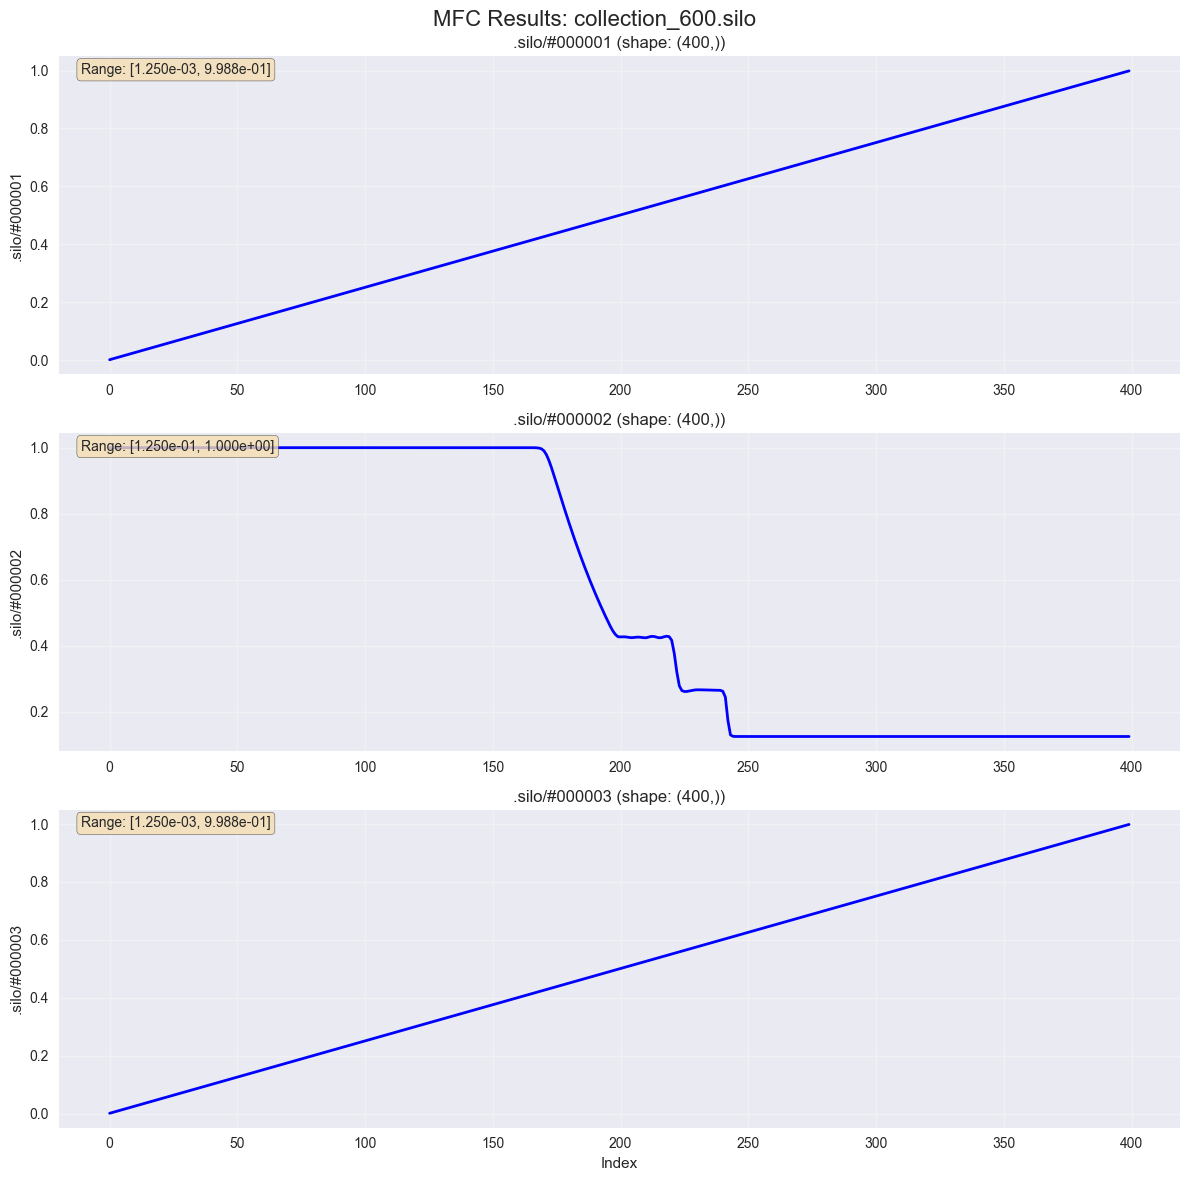

   ✅ Plotted 3 variables
✅ HDF5-Silo analysis completed successfully


In [8]:
# Analyze results from the demo run
try:
    if run_result and run_result['success']:
        print("🔍 Analyzing demo results...")
        analyze_results(run_result)
    elif run_result:
        print("❌ Cannot analyze - demo run failed")
        print(f"   Error: {run_result.get('stderr', 'Unknown error')}")
    else:
        print("❌ No results to analyze")
        print("   Make sure the previous cell ran an example successfully")
        
except NameError:
    print("❌ No run_result found - run the demo cell first")
    
except Exception as e:
    print(f"❌ Analysis failed: {e}")
    print("   Check if the demo run generated output files")
